---
title: The Maximal Coverage Location Problem (MCLP)
image: image.png
toc: true
execute: 
  enabled: true
---

The maximal location covering problem tries to optimize for a different objective to p-median and p-center and their variants. 

In p-median, we are trying to minimize the weighted travel time - so we care about the average time people will travel to get to a site. 

In p-center, we are trying to minimize the maximum travel time - so we'll potentially accept a slightly longer travel time on average if it means that

In MCLP, we are trying to maximise coverage within a given distance or travel time -- by default, the proportion of **demand** (people) within that threshold. 

For example, let's imagine we have 100 LSOAs in our problem, and we've calculated the travel time from each LSOA centroid to the possible sites, along with how many people live in each one.

Like with other problems, we'll work out the closest site to each LSOA for any given combination of sites. 

However, rather than just taking this travel time and using it for calculating an average or a maximum, we'll instead check it against a defined number - say 10 minutes. 

If the travel time from that LSOA to its nearest site in this configuration is less than 10 minutes, we'll record a 1, weighted by that LSOA's demand. 

If the travel time is instead greater than or equal to 10 minutes, we'll record a 0. 

We then do this for every LSOA, and add up the demand-weighted total. If the LSOAs within 10 minutes account for 64% of the total demand across all LSOAs, our output value is 0.64, or 64%. 

We might have a different solution where 68% of demand is within 10 minutes of a site. This could well have a worse average or maximum travel time - but if we're solving the MCLP, we'd rank the solution with the higher demand-weighted coverage as a better solution regardless of the other metrics. 

:::{.callout-note}
lokigi also always reports a second column, `proportion_regions_within_coverage_threshold`, which counts every LSOA equally rather than weighting by demand -- the "68 of 100 LSOAs" version of the same idea. The two coincide only when demand is uniform across regions, including whenever `.add_demand()` is never called at all. See the [regional vs. demand-weighted coverage example](../coverage_metrics/index.ipynb) for a case where they diverge and even favour different site combinations.
:::

Let's now try solving one of these problems. 

For the maximal location covering problem, we can set up our problem just like before.

In [1]:
from lokigi.site import SiteProblem

problem = SiteProblem()

problem.add_demand(
    "../../../sample_data/brighton_demand.csv",
    demand_col="demand",
    location_id_col="LSOA"
    )

problem.add_sites(
    "../../../sample_data/brighton_sites_named.geojson",
    candidate_id_col="site"
    )

problem.add_travel_matrix(
    travel_matrix_df="../../../sample_data/brighton_travel_matrix_driving_named.csv",
    source_col="LSOA",
    from_unit="seconds",
    to_unit="minutes"
    )

problem.add_region_geometry_layer(
    "https://github.com/hsma-programme/h6_3d_facility_location_problems/raw/refs/heads/main/h6_3d_facility_location_problems/example_code/LSOA_2011_Boundaries_Super_Generalised_Clipped_BSC_EW_V4.geojson",
    common_col="LSOA11NM"
    )

When we go to solve, we change our objective to "mclp".

We also need to pass in a new parameter - a 'threshold_for_coverage'. 

This is a value in the same units as our travel matrix that represents the threshold we care about. 

:::{.callout-note}
In this case, our travel matrix is in minutes, so we'd interpret this as us being interested in maximising the coverage of people within 10 **minutes** of a site. 

If our travel matrix was instead looking at the number of miles, the value we pass in to this argument wouldn't change - just our interpretation of it. 
:::

In [2]:
solutions = problem.solve(
    objectives="mclp",
    p=3,
    threshold_for_coverage=10
    )

  0%|          | 0/20 [00:00<?, ?it/s]

We can now see our solutions, paying particular attention to the column 'proportion_within_coverage_threshold' -- the demand-weighted coverage. There's also a 'proportion_regions_within_coverage_threshold' column, which counts every LSOA equally instead; the two are identical throughout this example since we never called `.add_demand()`. 

:::{.callout-note}
If two solutions tie on 'proportion_within_coverage_threshold', ties are broken by ordering on the weighted average travel time. Note that if you haven't provided demand, the demand will be assumed to be equal across all regions, so weighted_average=unweighted_average in that context. 
:::

In [3]:
solutions.show_solutions()

,solution_rank,site_names,site_indices,coverage_threshold,weighted_average,unweighted_average,90th_percentile,max,total_cost,proportion_within_coverage_threshold,...,gap_absolute_weighted,gap_relative_weighted,avg_lower_third_bins,avg_middle_third_bins,avg_upper_third_bins,inter_tertile_ratio,gap_absolute_description,gap_relative_description,inter_tertile_description,problem_df
0,1,"[Tulip (Site 3), Daisy (Site 4), Daffodil (Sit...","[2, 3, 4]",10,5.37,5.45,8.50,16.69,NaN,0.96,...,None,None,None,None,None,None,N/A (No equity data),N/A (No equity data),N/A (No equity data),LSOA Tulip (Site 3) D...
1,2,"[Tulip (Site 3), Daisy (Site 4), Snowdrop (Sit...","[2, 3, 5]",10,5.38,5.36,8.06,16.69,NaN,0.95,...,None,None,None,None,None,None,N/A (No equity data),N/A (No equity data),N/A (No equity data),LSOA Tulip (Site 3) D...
2,3,"[Begonia (Site 2), Tulip (Site 3), Daisy (Site...","[1, 2, 3]",10,5.54,5.59,9.00,16.69,NaN,0.94,...,None,None,None,None,None,None,N/A (No equity data),N/A (No equity data),N/A (No equity data),LSOA Begonia (Site 2) ...
3,4,"[Dahlia (Site 1), Tulip (Site 3), Snowdrop (Si...","[0, 2, 5]",10,6.32,6.21,9.33,16.69,NaN,0.94,...,None,None,None,None,None,None,N/A (No equity data),N/A (No equity data),N/A (No equity data),LSOA Dahlia (Site 1) ...
4,5,"[Tulip (Site 3), Daffodil (Site 5), Snowdrop (...","[2, 4, 5]",10,6.42,6.29,9.26,16.69,NaN,0.93,...,None,None,None,None,None,None,N/A (No equity data),N/A (No equity data),N/A (No equity data),LSOA Tulip (Site 3) D...
5,6,"[Dahlia (Site 1), Tulip (Site 3), Daisy (Site 4)]","[0, 2, 3]",10,5.53,5.67,9.36,16.69,NaN,0.93,...,None,None,None,None,None,None,N/A (No equity data),N/A (No equity data),N/A (No equity data),LSOA Dahlia (Site 1) ...
6,7,"[Begonia (Site 2), Tulip (Site 3), Snowdrop (S...","[1, 2, 5]",10,6.51,6.31,9.45,16.69,NaN,0.92,...,None,None,None,None,None,None,N/A (No equity data),N/A (No equity data),N/A (No equity data),LSOA Begonia (Site 2) ...
7,8,"[Dahlia (Site 1), Tulip (Site 3), Daffodil (Si...","[0, 2, 4]",10,6.35,6.32,9.70,16.69,NaN,0.90,...,None,None,None,None,None,None,N/A (No equity data),N/A (No equity data),N/A (No equity data),LSOA Dahlia (Site 1) ...
8,9,"[Dahlia (Site 1), Begonia (Site 2), Tulip (Sit...","[0, 1, 2]",10,6.47,6.39,9.77,16.69,NaN,0.89,...,None,None,None,None,None,None,N/A (No equity data),N/A (No equity data),N/A (No equity data),LSOA Dahlia (Site 1) ...
9,10,"[Begonia (Site 2), Daisy (Site 4), Daffodil (S...","[1, 3, 4]",10,6.92,6.76,11.32,21.71,NaN,0.82,...,None,None,None,None,None,None,N/A (No equity data),N/A (No equity data),N/A (No equity data),LSOA Begonia (Site 2) ...


Let's have a quick look at what the underlying data looks like for the best solution. We can see that there is a 'within_threshold' column with values of True (1) and False (0). 

In [4]:
solutions.show_solutions()["problem_df"][0]

,LSOA,Tulip (Site 3),Daisy (Site 4),Daffodil (Site 5),min_cost,selected_site,within_threshold,demand
0,Brighton and Hove 027E,7.404833,8.197500,10.125667,7.404833,Tulip (Site 3),True,3627
1,Brighton and Hove 027F,8.626167,9.351167,9.649500,8.626167,Tulip (Site 3),True,2323
2,Brighton and Hove 027A,8.633000,6.840000,11.353833,6.840000,Daisy (Site 4),True,2596
3,Brighton and Hove 029E,11.006000,6.328667,12.193000,6.328667,Daisy (Site 4),True,3132
4,Brighton and Hove 029D,10.970000,5.216667,12.408333,5.216667,Daisy (Site 4),True,2883
...,...,...,...,...,...,...,...,...
160,Brighton and Hove 012A,18.468500,8.652667,10.433667,8.652667,Daisy (Site 4),True,2497
161,Brighton and Hove 005C,16.804000,9.490000,8.769167,8.769167,Daffodil (Site 5),True,2570
162,Brighton and Hove 012B,18.876667,8.952500,10.841833,8.952500,Daisy (Site 4),True,2051
163,Brighton and Hove 005A,18.432167,11.068500,10.397333,10.397333,Daffodil (Site 5),False,1164


Let's now plot our best combination.

Note that the plot title automatically updates to include the coverage. 

:::{.callout-tip}
If we are working in a Jupyter notebook, we can prevent any additional output displaying from the mapping functions by ending our code with a semicolon.
:::

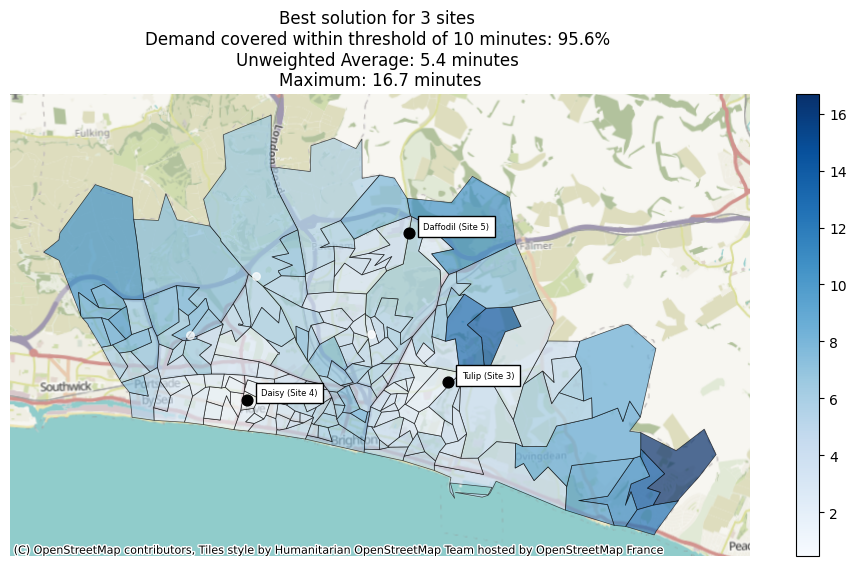

In [5]:
solutions.plot_best_combination();

Let's take a quick look at which regions have been allocated to each site in our best solution. 

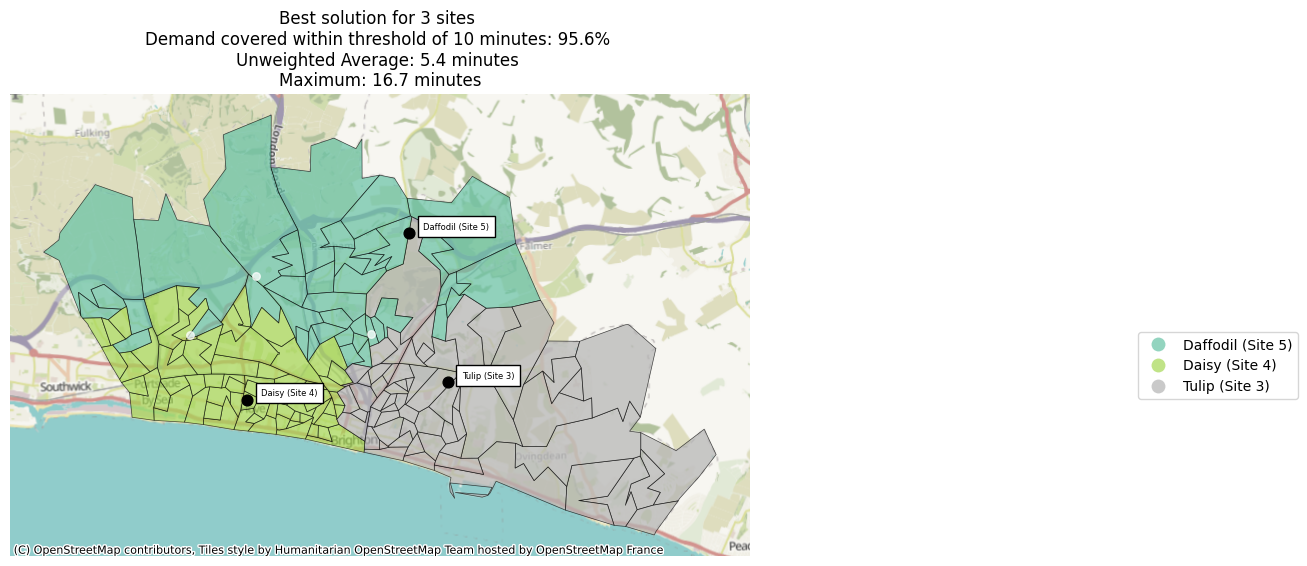

In [6]:
solutions.plot_best_combination(plot_site_allocation=True);

As we've set a threshold, we can now do a new type of plot, where we can colour each region by whether or not it meets the threshold we've defined. 

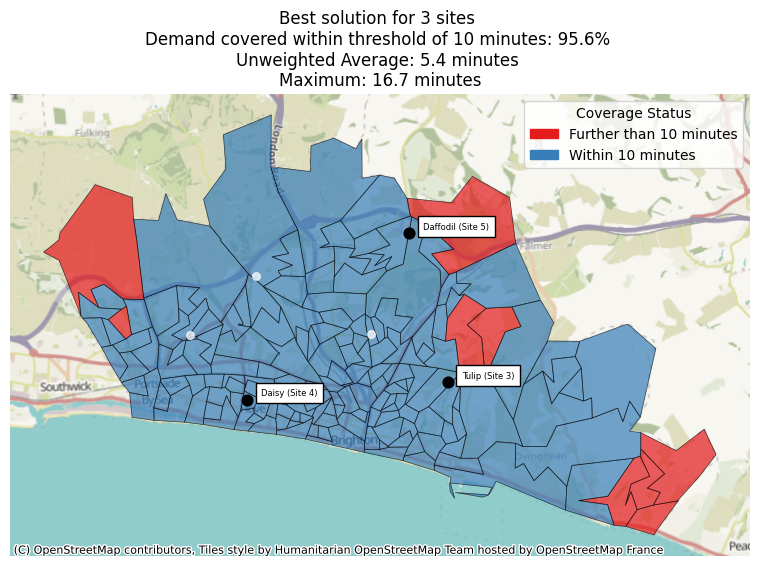

In [7]:
solutions.plot_best_combination(
    plot_regions_not_meeting_threshold=True,
    show_all_locations=True, unchosen_site_colour="white"
    );

Let's now plot the weighted travel time for the best 10 combinations. 

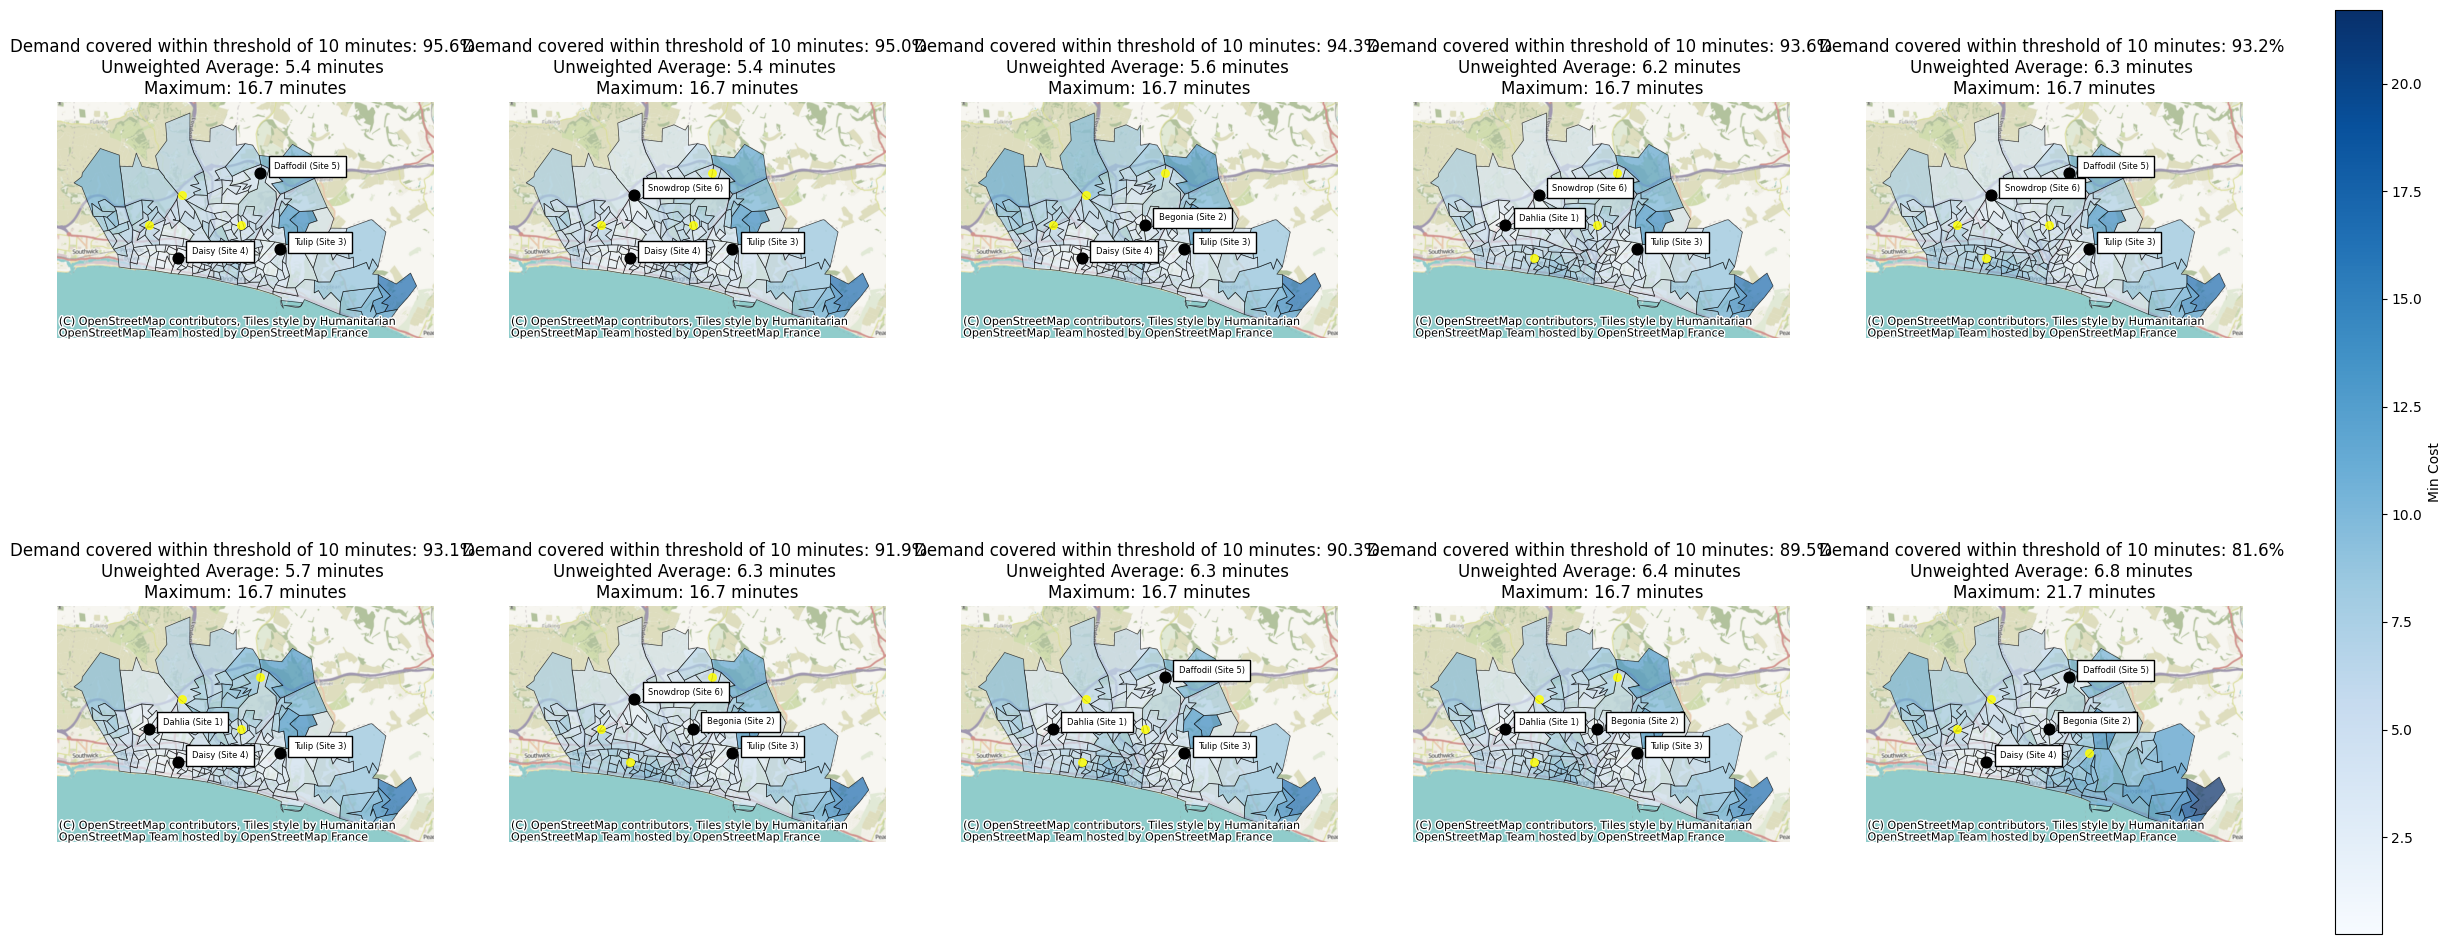

In [8]:
solutions.plot_n_best_combinations(unchosen_site_colour="yellow", unchosen_site_opacity=0.8);

We can also use the `plot_regions_not_meeting_threshold` parameter in the `.plot_n_best_combinations` method. 

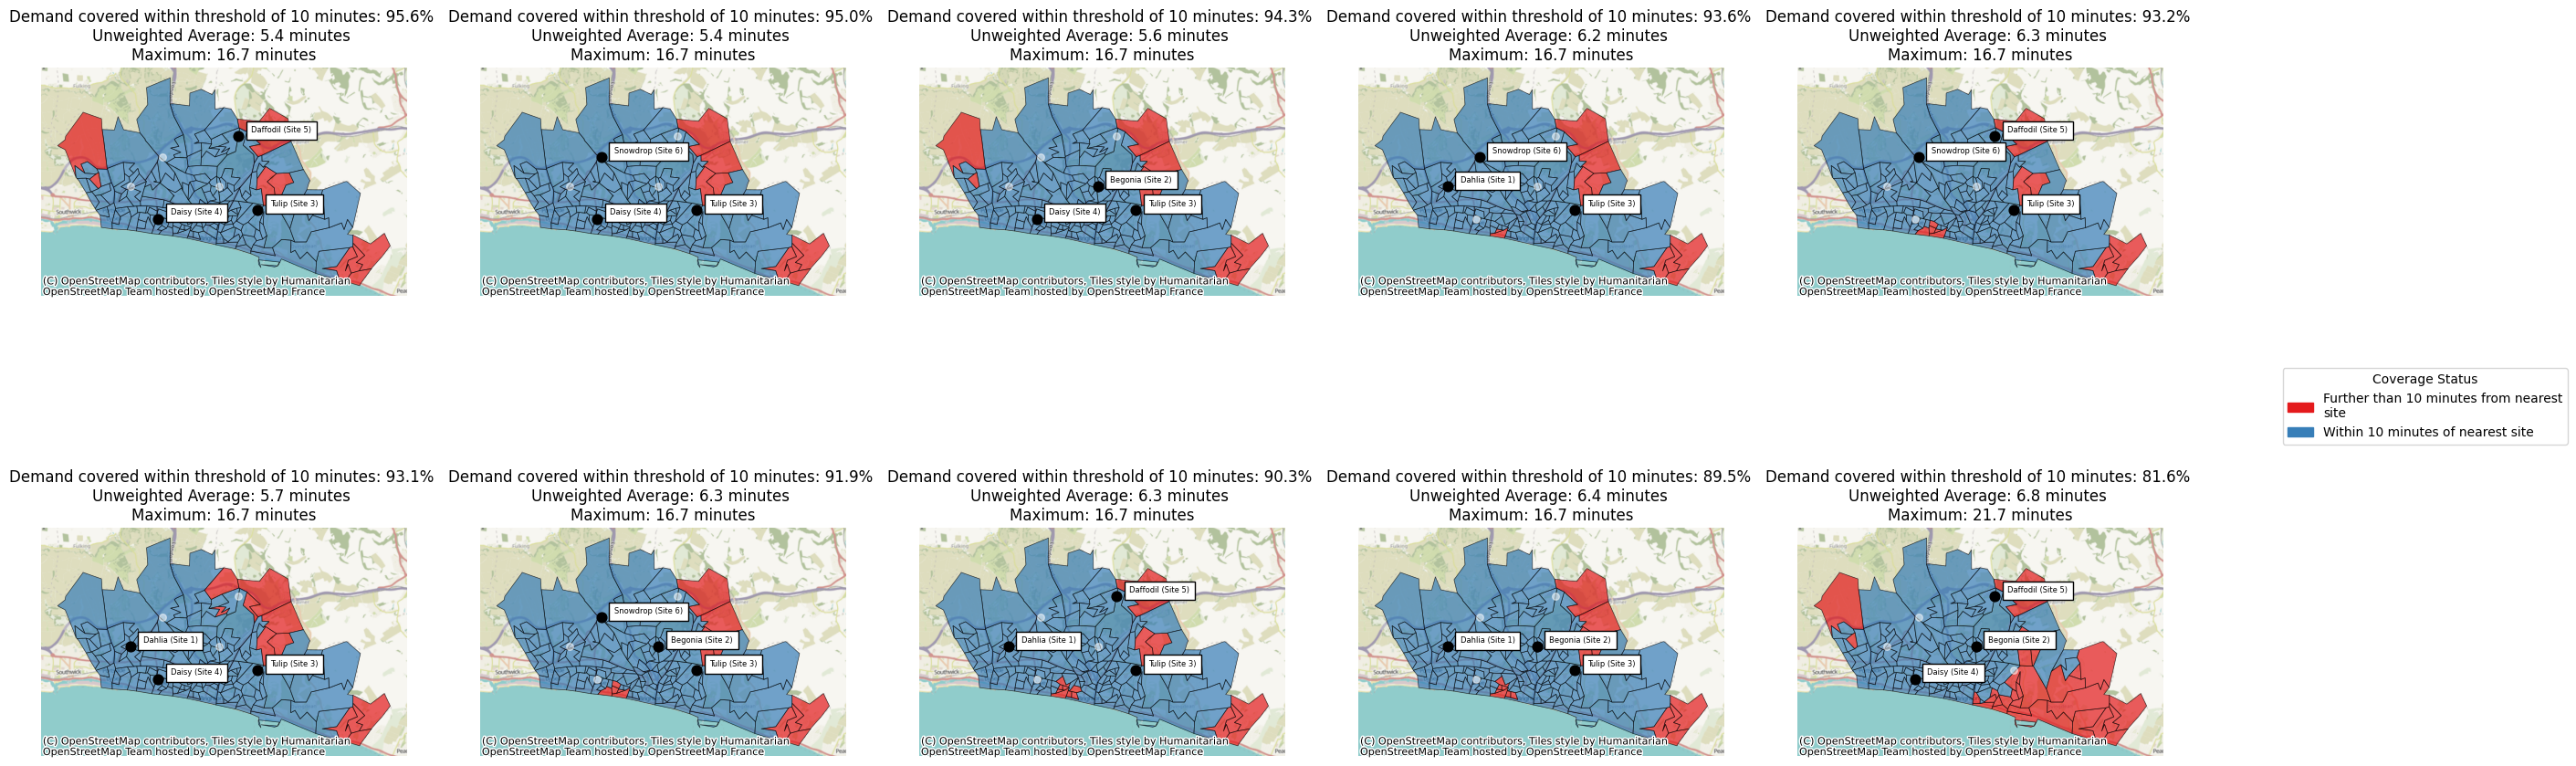

In [9]:
solutions.plot_n_best_combinations(plot_regions_not_meeting_threshold=True);

We may also want to plot the pareto fronts to compare trade-offs with coverage. 

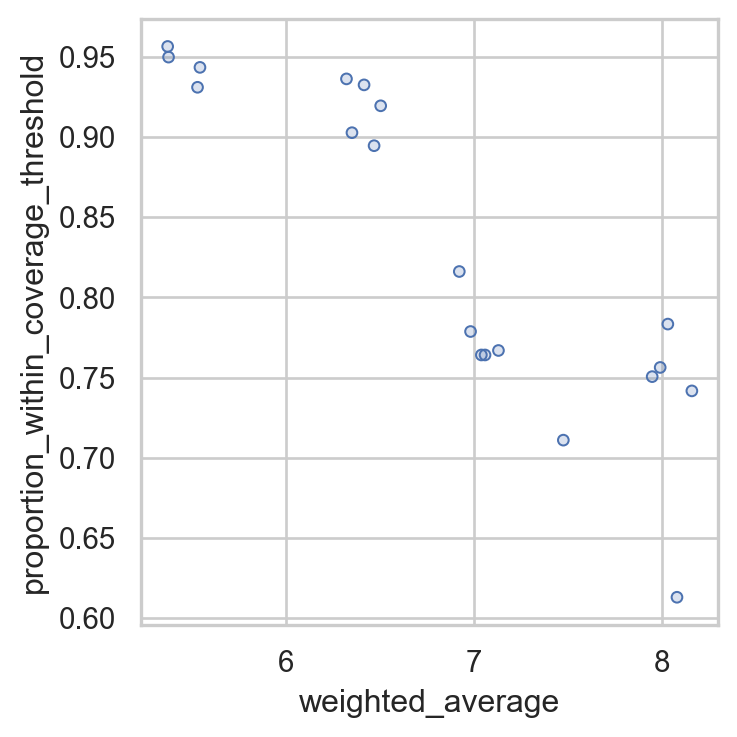

In [10]:
solutions.plot_simple_pareto_front_pairs("weighted_average", "proportion_within_coverage_threshold")

In this case, the best solution for coverage is also the best solution for weighted average travel time, so there is no line indicating a pareto front plotted as there is no trade-off to be made in this instance. We want to maximise the proportion within coverage threshold and minimize the weighted average travel time, so the point in the top left hand corner of this plot is the best at both. 

However, we can see that there is significant variation in weighted travel time across the 8 solutions that exceed 90% coverage within 10 minutes - so it's definitely worth being mindful of that when suggesting solutions to our stakeholders! 